# Nhận Dạng Biển Số Xe Việt Nam (ALPR)
### Notebook Huấn Luyện - YOLOv8 (Phát Hiện) + EasyOCR (OCR)

---

## Notebook này làm gì

Huấn luyện mô hình YOLOv8 để phát hiện vị trí biển số xe trong ảnh xe cộ Việt Nam.

| Bước | Nội dung |
|------|----------|
| 1 | Cài đặt & import thư viện |
| 2 | Kiểm tra dataset (train/valid/test splits) |
| 3 | Huấn luyện YOLOv8 + xem kết quả |
| 4 | Lưu mô hình tốt nhất (`best_vietnam_lpr.pt`) |

---

## Script inference (file riêng)

Sau khi huấn luyện, dùng các script Python độc lập này để kiểm tra mô hình:

| File | Cách dùng |
|------|-----------|
| `lpr_pipeline.py` | Module cốt lõi — class `LicensePlateRecognizer` |
| `test_image.py` | `python test_image.py --image photo.jpg` |
| `run_webcam.py` | `python run_webcam.py` |
| `run_video.py` | `python run_video.py --video clip.mp4` |

---

## Yêu Cầu Phần Cứng

**GPU NVIDIA (khuyến nghị):** huấn luyện nhanh (30–60 phút cho 100 epoch)  
**Chỉ CPU:** vẫn chạy được, nhưng chậm hơn (1–3 giờ)



---
# BƯỚC 1: Cài Đặt Thư Viện

Ô này cài đặt các thư viện Python cần thiết. Chỉ chạy một lần.

**Danh sách thư viện:**
- `ultralytics`: Framework YOLOv8 chính thức từ Ultralytics
- `paddlepaddle` + `paddleocr`: Thư viện OCR của Baidu, hỗ trợ nhiều ngôn ngữ
- `opencv-python`: Xử lý ảnh và video
- `matplotlib`, `pillow`, `pyyaml`: Thư viện hỗ trợ


In [1]:
# ============================================================
# CÀI ĐẶT THƯ VIỆN
# ============================================================

import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Đang cài đặt thư viện...")

# YOLOv8 - framework phát hiện đối tượng chính
install("ultralytics")

# PaddleOCR - đọc ký tự biển số
install("paddlepaddle")
install("paddleocr")

# OpenCV - xử lý ảnh và video
install("opencv-python")

# Các thư viện hỗ trợ
install("matplotlib")
install("pillow")
install("pyyaml")

print("[DONE] Cài đặt xong!")


Dang cai dat thu vien...
[DONE] Cai dat xong!


In [ ]:
# ============================================================
# IMPORT THƯ VIỆN
# ============================================================

import os
import shutil
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from IPython.display import display, clear_output

# Kiểm tra GPU
import torch
print(f"Phiên bản PyTorch: {torch.__version__}")
print(f"GPU khả dụng: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[CẢNH BÁO] Không tìm thấy GPU! Quá trình huấn luyện sẽ chậm hơn.")

print("\n[DONE] Import thư viện thành công!") 


PyTorch version: 2.6.0+cu124
GPU available: True
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU

[DONE] Libraries imported!


---
# BƯỚC 2: Kiểm Tra Dataset

## Cấu Trúc Thư Mục

Notebook trong `notebooks/`; dataset trong `dataset/` (cùng cấp `lpr_pipeline.py`).

```
vietnam_ipr/
    notebooks/
        vietnam_lpr_training.ipynb
    dataset/
        data.yaml
        train/images/
        valid/images/
        test/images/
```

**cwd:** `vietnam_ipr` hoặc `vietnam_ipr/notebooks` đều được - ô cấu hình tự tìm `dataset/data.yaml` và `os.chdir` về root để `runs/` ghi đúng.

Train dùng `dataset/data.yaml`. Hoặc từ terminal (root): `yolo train data=config/data.yaml`.



In [ ]:
# ============================================================
# CẤU HÌNH ĐƯỜNG DẪN DATASET (root repo hoặc notebooks/)
# ============================================================
from pathlib import Path


def _resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd.parent):
        if (base / "dataset" / "data.yaml").is_file():
            return base
    raise FileNotFoundError(
        "Không thấy dataset/data.yaml. Hãy chọn cwd là thư mục gốc project "
        "(vietnam_ipr) hoặc vietnam_ipr/notebooks rồi chạy lại ô này."
    )


PROJECT_ROOT = _resolve_project_root()
DATASET_PATH = str(PROJECT_ROOT / "dataset")

# Ultralytics ghi runs/ theo cwd - neo về root repo để không lệch vào notebooks/runs
os.chdir(PROJECT_ROOT)
print(f"[OK] PROJECT_ROOT = {PROJECT_ROOT}")

if os.path.exists(DATASET_PATH):
    print(f"[OK] Tìm thấy dataset tại: {DATASET_PATH}")
    contents = os.listdir(DATASET_PATH)
    print(f"     Nội dung: {contents}")
    for split in ["train", "valid", "test"]:
        img_path = os.path.join(DATASET_PATH, split, "images")
        if os.path.exists(img_path):
            count = len(
                [
                    f
                    for f in os.listdir(img_path)
                    if f.endswith((".jpg", ".jpeg", ".png"))
                ]
            )
            print(f"     {split}: {count} ảnh")
else:
    print(f"[LỖI] Không tìm thấy dataset tại: {DATASET_PATH}")



[OK] Found dataset at: C:\Users\Admin\Downloads\vietnam_ipr\dataset
     Contents: ['data.yaml', 'README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']
     train: 1423 images
     valid: 407 images
     test: 203 images


In [4]:
# ============================================================
# KIỂM TRA FILE data.yaml
# ============================================================
# File data.yaml cho YOLOv8 biết:
#   - Đường dẫn đến các tập train/valid/test
#   - Số lượng lớp (nc)
#   - Tên của từng lớp
#
# Dataset này có 3 lớp:
#   0: car (xe hơi)
#   1: motorcycle (xe máy)
#   2: plate (biển số) <-- Lớp chính để phát hiện biển số

yaml_path = os.path.join(DATASET_PATH, 'data.yaml')

if os.path.exists(yaml_path):
    print(f"[OK] Tìm thấy data.yaml tại: {yaml_path}")
    
    # Đọc và hiển thị nội dung
    with open(yaml_path, 'r', encoding='utf-8') as f:
        content = yaml.safe_load(f)
    
    print("\nNội dung data.yaml:")
    print(yaml.dump(content, default_flow_style=False))
    
    DATA_YAML_PATH = yaml_path
    
    # Hiển thị thông tin lớp
    print(f"\nSố lượng lớp: {content.get('nc', 'N/A')}")
    print(f"Tên các lớp: {content.get('names', 'N/A')}")
    print("\n[LƯU Ý] Lớp 'plate' (id=2) là lớp chính để phát hiện biển số!")
    
else:
    print(f"[LỖI] Không tìm thấy data.yaml tại: {yaml_path}")
    print("       Vui lòng kiểm tra lại đường dẫn dataset.")


[OK] Found data.yaml at: C:\Users\Admin\Downloads\vietnam_ipr\dataset\data.yaml

data.yaml contents:
names:
  0: car
  1: motorcycle
  2: plate
nc: 3
path: C:/Users/Admin/Downloads/vietnam_ipr/dataset
test: test/images
train: train/images
val: valid/images


Number of classes: 3
Class names: {0: 'car', 1: 'motorcycle', 2: 'plate'}

[NOTE] Class 'plate' (id=2) is the main class for plate detection!


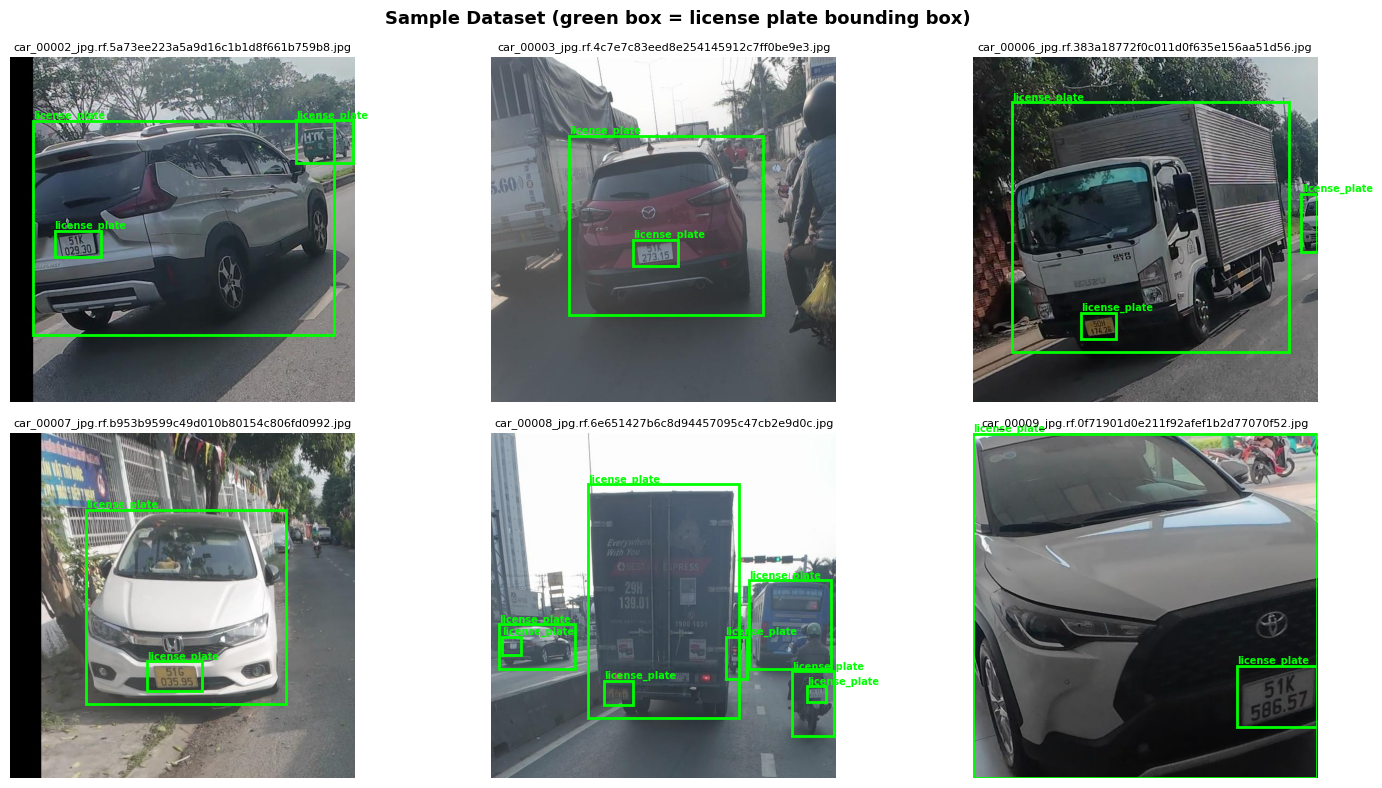

[OK] Dataset looks good! Annotations present.


In [5]:
# ============================================================
# HIỂN THỊ MẪU DATASET ĐỂ KIỂM TRA
# ============================================================
# Trước khi huấn luyện, xem một số ảnh để đảm bảo annotation đúng

def show_sample_with_bbox(img_path, label_path, ax):
    """Vẽ ảnh kèm bounding box từ nhãn YOLO"""
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis('off')
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                # Định dạng YOLO: class x_center y_center width height
                cls, xc, yc, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                
                # Chuyển sang pixel để vẽ
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                box_w = bw * w
                box_h = bh * h
                
                rect = patches.Rectangle(
                    (x1, y1), box_w, box_h,
                    linewidth=2, edgecolor='lime', facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x1, y1-5, 'bien_so', color='lime', fontsize=7, weight='bold')

def find_image_label_pairs(dataset_path, split='train', max_samples=6):
    """Tìm các cặp (ảnh, nhãn) từ dataset"""
    pairs = []
    
    img_dir = os.path.join(dataset_path, split, 'images')
    label_dir = os.path.join(dataset_path, split, 'labels')
    
    if not os.path.exists(img_dir):
        return []
    
    for f in sorted(os.listdir(img_dir))[:max_samples]:
        if f.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(img_dir, f)
            label_name = os.path.splitext(f)[0] + '.txt'
            label_path = os.path.join(label_dir, label_name) if label_dir else ''
            pairs.append((img_path, label_path))
    
    return pairs

if os.path.exists(DATASET_PATH):
    pairs = find_image_label_pairs(DATASET_PATH, 'train')
    
    if pairs:
        n = min(len(pairs), 6)
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = axes.flatten()
        
        for i, (img_path, label_path) in enumerate(pairs[:n]):
            show_sample_with_bbox(img_path, label_path, axes[i])
        
        for j in range(n, len(axes)):
            axes[j].axis('off')
        
        plt.suptitle('Mẫu Dataset (ô xanh = bounding box biển số)', fontsize=13, weight='bold')
        plt.tight_layout()
        plt.show()
        
        print("[OK] Dataset trông ổn! Có annotation đầy đủ.")
    else:
        print("[LỖI] Không tìm thấy ảnh trong dataset.")
else:
    print("[LỖI] Dataset chưa sẵn sàng.")


---
# BƯỚC 3: Huấn Luyện Mô Hình YOLOv8

## YOLOv8 Là Gì?

YOLO (You Only Look Once) là một họ các mô hình học sâu dùng để phát hiện đối tượng trong ảnh. Đặc điểm:

- **Nhanh**: Chỉ cần một lần duyệt qua ảnh (phát hiện một lượt)
- **Chính xác**: Đạt kết quả tốt trên nhiều bộ benchmark
- **Dễ dùng**: API đơn giản, chỉ vài dòng code

## Các Phiên Bản Mô Hình

| Mô hình | Kích thước | Tốc độ | Độ chính xác | Khi nào dùng |
|---------|-----------|--------|-------------|--------------|
| yolov8n (nano) | 3.2MB | Rất nhanh | Thấp nhất | CPU, Raspberry Pi |
| yolov8s (small) | 11.2MB | Nhanh | Tốt | GPU trung bình (khuyến nghị) |
| yolov8m (medium) | 25.9MB | Trung bình | Cao | GPU mạnh |

## Fine-tuning Là Gì?

Thay vì huấn luyện từ đầu (mất vài ngày), chúng ta dùng **trọng số đã được huấn luyện sẵn** — các mô hình đã được train trên ImageNet (hàng triệu ảnh). Sau đó **fine-tune** trên dataset biển số xe của chúng ta. Cách này nhanh hơn rất nhiều (30–60 phút).

## Các Siêu Tham Số Quan Trọng

- **epochs**: Số lần lặp qua toàn bộ dataset. Nhiều hơn = học tốt hơn, nhưng quá nhiều có thể gây overfitting.
- **batch_size**: Số ảnh xử lý cùng một lúc. Lớn hơn = nhanh hơn nhưng tốn nhiều RAM/VRAM.
- **imgsz**: Kích thước resize ảnh. Lớn hơn = chính xác hơn nhưng chậm hơn.
- **patience**: Dừng sớm nếu không cải thiện sau số epoch này.


In [ ]:
# ============================================================
# HUẤN LUYỆN YOLOV8
# ============================================================
from ultralytics import YOLO

# ---- Kiểm tra GPU ----
import torch
HAS_GPU = torch.cuda.is_available()
print(f"GPU khả dụng: {HAS_GPU}")
if HAS_GPU:
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")


# Kích thước mô hình (ưu tiên weights/pretrained nếu có)
MODEL_SIZE = "yolov8s.pt" if HAS_GPU else "yolov8n.pt"
_pretrained = PROJECT_ROOT / "weights" / "pretrained" / MODEL_SIZE
MODEL_ENTRY = str(_pretrained) if _pretrained.is_file() else MODEL_SIZE

# Số epoch
EPOCHS = 100 if HAS_GPU else 50

# Kích thước ảnh
IMG_SIZE = 640 if HAS_GPU else 416

# Kích thước batch
BATCH_SIZE = 16 if HAS_GPU else 4

# Workers - Windows + Jupyter thường ổn hơn với 0
import platform

WORKERS = 0 if platform.system() == "Windows" else (4 if HAS_GPU else 0)

PROJECT_NAME = 'vietnam_lpr'
RUN_NAME = 'yolov8_local'

# ---- Bắt đầu huấn luyện ----
print(f"\nCấu hình huấn luyện:")
print(f"   Mô hình: {MODEL_ENTRY}")
print(f"   Số epoch: {EPOCHS}")
print(f"   Kích thước ảnh: {IMG_SIZE}")
print(f"   Kích thước batch: {BATCH_SIZE}")
print(f"   Workers: {WORKERS}")
print(f"   Dataset: {DATA_YAML_PATH}")

if not HAS_GPU:
    print("\n[CẢNH BÁO] Đang huấn luyện trên CPU - sẽ mất 1-3 giờ")
    print("            Nếu quá chậm, hãy giảm EPOCHS xuống còn 30")
else:
    print("\nDự kiến: 20-40 phút với GPU")

print("=" * 60)

model = YOLO(MODEL_ENTRY)


results = model.train(
    data=DATA_YAML_PATH,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=WORKERS,
    project=PROJECT_NAME,
    name=RUN_NAME,
    patience=20,          # Dừng sớm nếu không cải thiện
    save=True,
    plots=True,
    device=0 if HAS_GPU else 'cpu',
    
    # Tăng cường dữ liệu (data augmentation)
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
)

print("\n[DONE] Huấn luyện hoàn tất!")

possible_paths = [
    os.path.join('runs', 'detect', PROJECT_NAME, RUN_NAME, 'weights', 'best.pt'),
    os.path.join(PROJECT_NAME, RUN_NAME, 'weights', 'best.pt'),
]

BEST_MODEL_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        BEST_MODEL_PATH = path
        break

if BEST_MODEL_PATH:
    print(f"Mô hình tốt nhất lưu tại: {BEST_MODEL_PATH}")
else:
    import glob
    found = glob.glob(f"runs/detect/**/best.pt", recursive=True)
    if found:
        BEST_MODEL_PATH = found[0]
        print(f"Tìm thấy mô hình tại: {BEST_MODEL_PATH}")
    else:
        BEST_MODEL_PATH = os.path.join(PROJECT_NAME, RUN_NAME, 'weights', 'best.pt')
        print(f"[CẢNH BÁO] Không tìm thấy mô hình. Dự kiến tại: {BEST_MODEL_PATH}")


GPU available: True
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU

Training config:
   Model: yolov8s.pt
   Epochs: 100
   Image size: 640
   Batch size: 16
   Workers: 4
   Dataset: C:\Users\Admin\Downloads\vietnam_ipr\dataset\data.yaml

Expected: 20-40 minutes with GPU


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


New https://pypi.org/project/ultralytics/8.4.40 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.13.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Admin\Downloads\vietnam_ipr\dataset\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mos

[OK] Found results folder: runs\detect\vietnam_lpr\yolov8_local


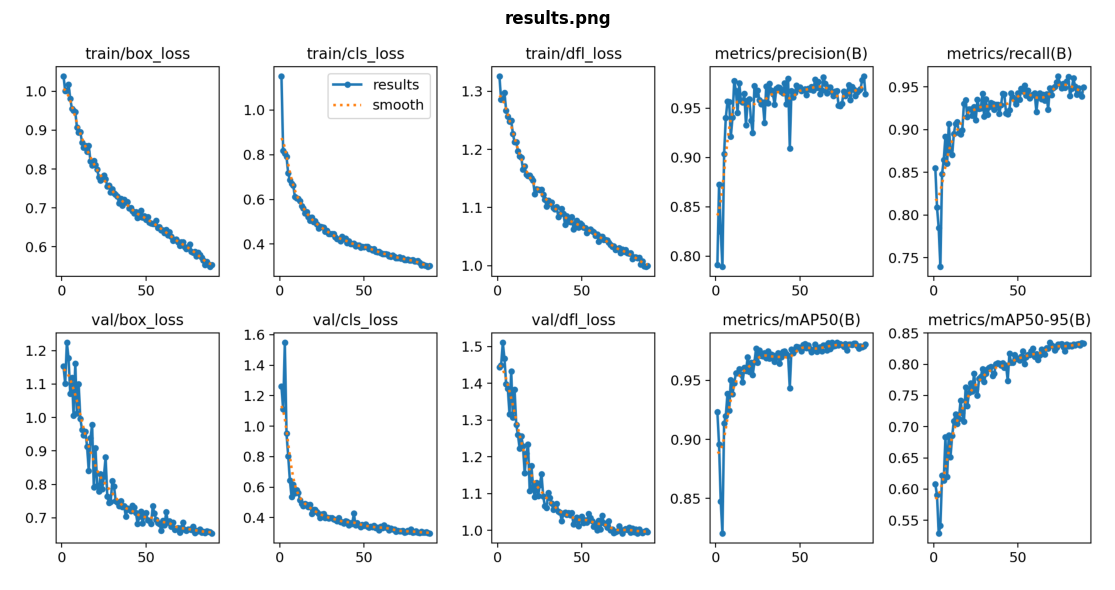

[OK] Displayed: results.png


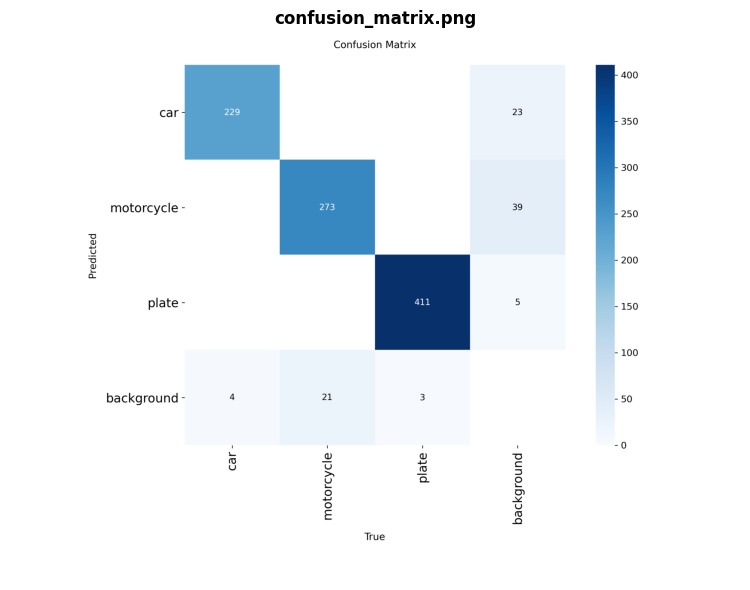

[OK] Displayed: confusion_matrix.png


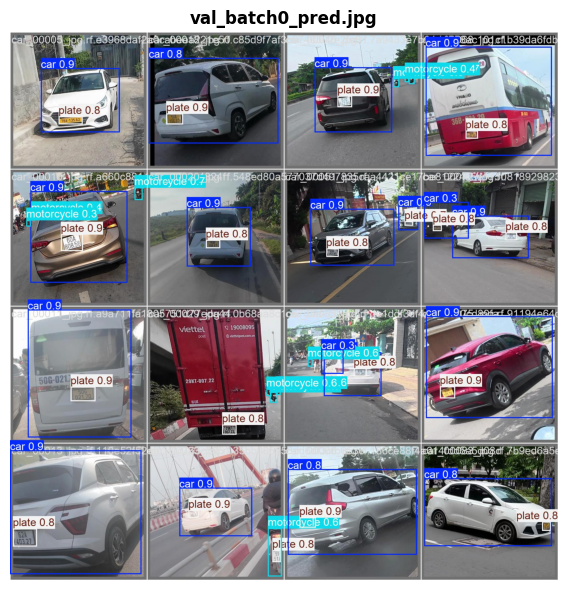

[OK] Displayed: val_batch0_pred.jpg

=== METRIC EXPLANATION ===

mAP50 (Mean Average Precision @ IoU 0.5):
   - Most important metric
   - > 0.90 = Excellent
   - > 0.80 = Acceptable
   - < 0.70 = Needs more data or training

Precision: Of all plates detected by the model,
   what % are correct? (Avoid false positives)

Recall: Of all plates in the image,
   what % did the model detect? (Avoid missing plates)

Ideal: Precision > 0.9 AND Recall > 0.9



In [7]:
# ============================================================
# XEM KẾT QUẢ HUẤN LUYỆN
# ============================================================

# Tìm thư mục kết quả - kiểm tra cả hai vị trí có thể
possible_results = [
    os.path.join('runs', 'detect', PROJECT_NAME, RUN_NAME),
    os.path.join(PROJECT_NAME, RUN_NAME),
]

results_dir = None
for path in possible_results:
    if os.path.exists(path):
        results_dir = path
        print(f"[OK] Tìm thấy thư mục kết quả: {results_dir}")
        break

if not results_dir:
    print("[LỖI] Không tìm thấy thư mục kết quả huấn luyện!")
    print("       Vui lòng chạy ô Huấn Luyện trước.")
else:
    # Hiển thị các biểu đồ huấn luyện nếu có
    plot_files = ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']

    for plot_file in plot_files:
        plot_path = os.path.join(results_dir, plot_file)
        if os.path.exists(plot_path):
            img = Image.open(plot_path)
            plt.figure(figsize=(14, 6))
            plt.imshow(img)
            plt.title(plot_file, fontsize=12, weight='bold')
            plt.axis('off')
            plt.tight_layout()
            plt.show()
            print(f"[OK] Đã hiển thị: {plot_file}")
        else:
            print(f"[CẢNH BÁO] Không tìm thấy: {plot_file}")

    # Giải thích các chỉ số quan trọng
    print("""
=== GIẢI THÍCH CÁC CHỈ SỐ ===

mAP50 (Mean Average Precision @ IoU 0.5):
   - Chỉ số quan trọng nhất
   - > 0.90 = Xuất sắc
   - > 0.80 = Chấp nhận được
   - < 0.70 = Cần thêm dữ liệu hoặc huấn luyện thêm

Precision (Độ chính xác): Trong tất cả biển số mô hình phát hiện,
   có bao nhiêu % là đúng? (Tránh false positive)

Recall (Độ bao phủ): Trong tất cả biển số trong ảnh,
   mô hình phát hiện được bao nhiêu %? (Tránh bỏ sót)

Lý tưởng: Precision > 0.9 VÀ Recall > 0.9
""")


---
# BƯỚC 6: Lưu Mô Hình và Triển Khai

Sau khi huấn luyện, bạn cần lưu mô hình để dùng về sau.

## Các File Quan Trọng

| File | Mô tả |
|------|-------|
| `best.pt` | Mô hình tốt nhất (dựa trên mAP trên tập validation) |
| `last.pt` | Mô hình từ epoch cuối cùng |
| `results.png` | Biểu đồ loss và metrics qua các epoch |
| `confusion_matrix.png` | Ma trận nhầm lẫn |

## Xuất Sang Định Dạng Khác

- **ONNX**: Inference nhanh hơn, triển khai được trên nhiều nền tảng
- **TensorRT**: Tối ưu cho GPU NVIDIA
- **CoreML**: Cho ứng dụng iOS/macOS
- **TFLite**: Cho Android và Raspberry Pi



In [8]:
# ============================================================
# LƯU MÔ HÌNH
# ============================================================
from ultralytics import YOLO

if os.path.exists(BEST_MODEL_PATH):
    print(f"[OK] Mô hình đã lưu tại: {BEST_MODEL_PATH}")

    weights_dir = PROJECT_ROOT / "weights"
    weights_dir.mkdir(parents=True, exist_ok=True)
    dest_pt = weights_dir / "best_vietnam_lpr.pt"
    shutil.copy(BEST_MODEL_PATH, dest_pt)
    print(f"[OK] Đã sao chép để dùng cho inference pipeline: {dest_pt}")

    print("\nĐang xuất sang ONNX...")
    try:
        yolo_model = YOLO(BEST_MODEL_PATH)
        onnx_path = yolo_model.export(format="onnx", imgsz=640, simplify=True)
        print(f"[OK] Đã xuất ONNX tại: {onnx_path}")
    except Exception as e:
        print(f"[CẢNH BÁO] Xuất ONNX thất bại: {e}")
        print("            Không sao, file .pt vẫn dùng được bình thường")

    print("\n" + "=" * 50)
    print("Huấn luyện hoàn tất! Các file quan trọng:")
    print(f"   - Weights inference: {dest_pt}")
    print(f"   - Output huấn luyện gốc: {BEST_MODEL_PATH}")
    results_folder = os.path.dirname(os.path.dirname(BEST_MODEL_PATH))
    print(f"   - Thư mục kết quả: {results_folder}")

else:
    print("[LỖI] Không tìm thấy mô hình. Vui lòng chạy bước Huấn Luyện trước.")




[OK] Model saved at: runs\detect\vietnam_lpr\yolov8_local\weights\best.pt
[OK] Model copied to: best_vietnam_lpr.pt

Exporting to ONNX...
Ultralytics 8.4.33  Python-3.13.7 torch-2.6.0+cu124 CPU (12th Gen Intel Core i5-12500H)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'runs\detect\vietnam_lpr\yolov8_local\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (21.5 MB)

ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success  3.1s, saved as 'runs\detect\vietnam_lpr\yolov8_local\weights\best.onnx' (42.7 MB)

Export complete (3.9s)
Results saved to C:\Users\Admin\Downloads\vietnam_ipr\runs\detect\vietnam_lpr\yolov8_local\weights
Predict:         yolo predict task=detect model=runs\detect\vietnam_lpr\yolov8_local\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs\detect\vietnam_lpr\yolov8_local\weights\best.onnx 